# Activity 3 — Sankey: Following the Flow
**DSC 402/502 · Proportions.** A Sankey shows *where volume goes* — flow that a bar chart buries. You'll build one, try different **node orderings** to see what makes it readable, then argue it against a stacked bar and a table.

*Run cells top to bottom.*

In [ ]:
import plotly.graph_objects as go
import pandas as pd, io

# Student flow: intended major -> declared major -> outcome (illustrative data)
CSV = '''source,target,value
Undecided,Biology (declared),18
Undecided,Business (declared),22
Undecided,Comp Sci (declared),15
Biology (intended),Biology (declared),44
Biology (intended),Health Sci (declared),16
Business (intended),Business (declared),60
Business (intended),Comp Sci (declared),15
Comp Sci (intended),Comp Sci (declared),52
Comp Sci (intended),Data Sci (declared),18
Biology (declared),Graduated,40
Biology (declared),Still enrolled,14
Biology (declared),Transferred out,8
Business (declared),Graduated,58
Business (declared),Still enrolled,16
Business (declared),Transferred out,8
Comp Sci (declared),Graduated,55
Comp Sci (declared),Still enrolled,18
Comp Sci (declared),Transferred out,9
Health Sci (declared),Graduated,11
Health Sci (declared),Still enrolled,4
Health Sci (declared),Transferred out,1
Data Sci (declared),Graduated,12
Data Sci (declared),Still enrolled,5
Data Sci (declared),Transferred out,1
'''
flows = pd.read_csv(io.StringIO(CSV))
flows.head(8)

,source,target,value
0,Undecided,Biology (declared),18
1,Undecided,Business (declared),22
2,Undecided,Comp Sci (declared),15
3,Biology (intended),Biology (declared),44
4,Biology (intended),Health Sci (declared),16
5,Business (intended),Business (declared),60
6,Business (intended),Comp Sci (declared),15
7,Comp Sci (intended),Comp Sci (declared),52


### Notice the labels
They say `Biology (intended)` and `Biology (declared)` **separately**. Why? (If both were just `Biology`, a student who *keeps* their major would loop back to the same node and draw as an ugly curl. Giving each stage its own label is the “shape the data for the mark” lesson.)

### 1. Build the Sankey (default layout)
Plotly needs **node indices**, not names, so we build a label→index map. Here Plotly arranges the nodes automatically. Hover a ribbon — its width is the number of students.

In [ ]:
labels = pd.unique(flows[['source','target']].values.ravel()).tolist()
idx = {name:i for i,name in enumerate(labels)}

fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=15, thickness=18),
    link=dict(source=flows['source'].map(idx),
              target=flows['target'].map(idx),
              value=flows['value'])))
fig.update_layout(title_text='Intended → declared major → outcome', font_size=12)
fig.show()

### 2. Read it
Which major **retains** the most of its intended students (fattest ribbon between the first two columns)? Which is a net **importer** of switchers?

### 3. Try different orderings: which reads best?
The **order of nodes within each column** decides how many ribbons cross — and crossings are what turn a Sankey into spaghetti. The helper below lets you set the top-to-bottom order of the nodes in each stage.

**# YOUR TURN:** try at least **two** orderings and keep the one you prefer. Ideas:
- **(a) alphabetical** within each column
- **(b) aligned** — put each major at roughly the same height across all three columns (Biology near Biology, etc.)
- **(c) by size** — biggest groups at the top

Which ordering has the **fewest crossing ribbons**? Which do you *prefer*, and why? (That ‘why’ is the point.)

In [ ]:
# Helper: set the top-to-bottom ORDER of nodes in each stage, then re-run.
# You do not need to modify this function, see comment below (starting with EDIT)
def sankey_ordered(flows, order, arrangement='snap'):   # try arrangement='fixed' for exact control
    labels = [n for st in order for n in order[st]]
    idx = {n:i for i,n in enumerate(labels)}
    ns = len(order); nx=[0.0]*len(labels); ny=[0.0]*len(labels)
    for st, nodes in order.items():
        x = 0.5 if ns==1 else st/(ns-1); x = min(max(x,0.001),0.999)
        for pos,name in enumerate(nodes):
            nx[idx[name]] = x; ny[idx[name]] = (pos+1)/(len(nodes)+1)
    fig = go.Figure(go.Sankey(arrangement=arrangement,
        node=dict(label=labels, x=nx, y=ny, pad=15, thickness=18),
        link=dict(source=flows['source'].map(idx),
                  target=flows['target'].map(idx), value=flows['value'])))
    fig.update_layout(title_text='Major flow — try reordering', font_size=12); return fig

# EDIT these lists to reorder each column (top -> bottom), then re-run the cell:
order = {
    0: ['Undecided','Biology (intended)','Business (intended)','Comp Sci (intended)'],
    1: ['Biology (declared)','Business (declared)','Comp Sci (declared)','Health Sci (declared)','Data Sci (declared)'],
    2: ['Graduated','Still enrolled','Transferred out'],
}
sankey_ordered(flows, order).show()

### 4. Compare against a stacked bar and a table
**# YOUR TURN:** make a stacked bar of the declared-major counts, and a plain table. What does the Sankey show that the bar cannot? Where would the **table** serve a reader better than either?

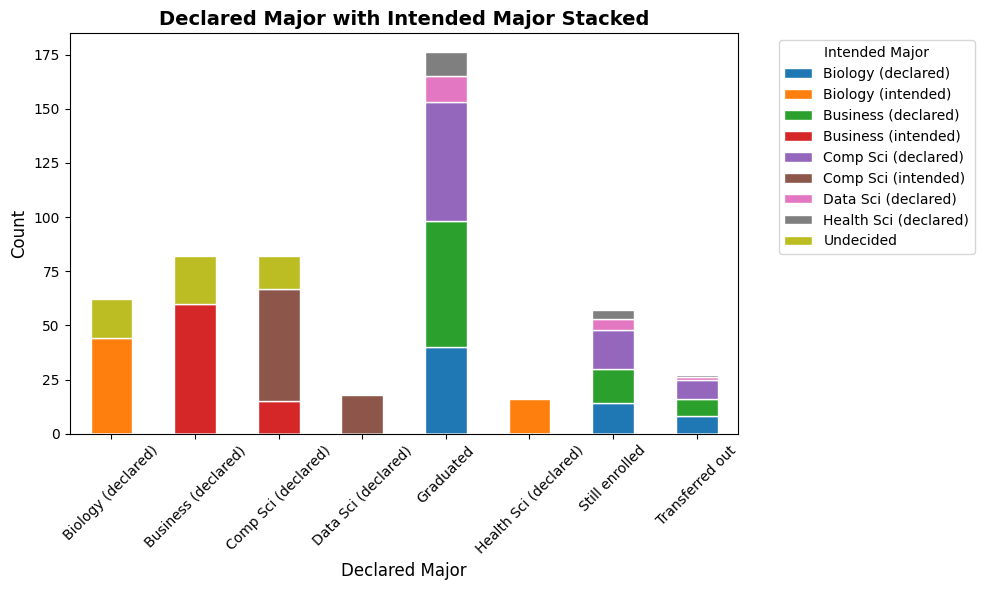

In [ ]:
# YOUR TURN: stacked bar / table of the same numbers
import matplotlib.pyplot as plt

# 1. Pivot the dataframe to set up the stacking structure
# This sets 'target' as the X-axis and splits 'source' into stacked layers
pivoted_df = flows.pivot(index='target', columns='source', values='value')

# 2. Plot the stacked bar chart
pivoted_df.plot(kind='bar', stacked=True, figsize=(10, 6), edgecolor='white')

# 3. Customize labels and appearance
plt.title('Declared Major with Intended Major Stacked', fontsize=14, fontweight='bold')
plt.xlabel('Declared Major', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)  # Puts target labels at 45 degree angle.
plt.legend(title='Intended Major', bbox_to_anchor=(1.05, 1), loc='upper left')  # Moves legend outside so it doesn't block the bars

plt.tight_layout()
plt.show()

In [ ]:
# Create the table matrix and replace missing tracks with 0
table_df = flows.pivot(index='source', columns='target', values='value').fillna(0).astype(int)

# This adds a subtle color gradient making high-density paths pop out instantly
table_df.style.background_gradient(cmap='Blues').format("{:,.0f}")

target,Biology (declared),Business (declared),Comp Sci (declared),Data Sci (declared),Graduated,Health Sci (declared),Still enrolled,Transferred out
source,,,,,,,,
Biology (declared),0,0,0,0,40,0,14,8
Biology (intended),44,0,0,0,0,16,0,0
Business (declared),0,0,0,0,58,0,16,8
Business (intended),0,60,15,0,0,0,0,0
Comp Sci (declared),0,0,0,0,55,0,18,9
Comp Sci (intended),0,0,52,18,0,0,0,0
Data Sci (declared),0,0,0,0,12,0,5,1
Health Sci (declared),0,0,0,0,11,0,4,1
Undecided,18,22,15,0,0,0,0,0


In [ ]:
order2 = {
    0: ['Graduated','Still enrolled','Transferred out'],
    1: ['Biology (declared)','Business (declared)','Comp Sci (declared)','Health Sci (declared)','Data Sci (declared)'],
    2: ['Undecided','Biology (intended)','Business (intended)','Comp Sci (intended)'],
}
sankey_ordered(flows, order2).show()

In [ ]:
order3 = {
    0: ['Graduated','Still enrolled','Transferred out'],
    1: ['Undecided','Biology (intended)','Business (intended)','Comp Sci (intended)'],
    2: ['Biology (declared)','Business (declared)','Comp Sci (declared)','Health Sci (declared)','Data Sci (declared)'],
}
sankey_ordered(flows, order3).show()